In [1]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

In [2]:
# ── 1) LOAD GRID ─────────────────────────────────────────────────────────────
shp_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Projects/Cartography/CONUS_5d_grid.shp"
grid = gpd.read_file(shp_path)

# Make sure we’re in geographic coordinates for Cartopy plotting
grid = grid.to_crs(epsg=4326)

# Column names holding your data
DIR_COL = "mean_dir_deg"      # degrees
MAG_COL = "mean_speed"        # optional; if not present we'll use ones

if MAG_COL not in grid.columns:
    grid[MAG_COL] = 1.0  # constant length if you don't have a magnitude

# (Optional) If your grid is very dense, downsample to avoid clutter:
# grid = grid.iloc[::3].copy()   # keep every 3rd cell, for example

In [3]:
# ── 2) CENTROIDS ─────────────────────────────────────────────────────────────

centroids = grid.geometry.centroid
xs = centroids.x.values
ys = centroids.y.values

# import CONUS results
conus_dir = pd.read_csv('/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS_storm_tracking/conus_storm_tracking_results.csv')

# magnitude (any units)

/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_67988/1683411859.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = grid.geometry.centroid


In [4]:
## put the centroid in the conus dir dataframe:
# Ensure the Domain column is set as the index
conus_dir.set_index('Domain', inplace=True)

for i, row in grid.iterrows():
    print(i, row['id'])
    domain = 'Domain_'+ str(int(row['id'])) + '.shp'
    conus_dir.loc[domain, 'centroid_x'] = grid[grid['id'] == row['id']].geometry.centroid.x.iloc[0]
    conus_dir.loc[domain, 'centroid_y'] = grid[grid['id'] == row['id']].geometry.centroid.y.iloc[0]

# Reset the index if needed later
conus_dir.reset_index(inplace=True)

0 49.0
1 52.0
2 58.0
3 59.0
4 57.0
5 60.0
6 102.0
7 103.0
8 32.0
9 33.0
10 39.0
11 42.0
12 40.0
13 41.0
14 86.0
15 87.0
16 84.0
17 22.0
18 85.0
19 23.0
20 21.0
21 94.0
22 24.0
23 95.0
24 30.0
25 93.0
26 66.0
27 31.0
28 67.0
29 3.0
30 68.0
31 69.0
32 75.0
33 4.0
34 5.0
35 78.0
36 79.0
37 76.0
38 77.0
39 14.0
40 15.0
41 12.0
42 13.0
43 50.0
44 51.0
45 48.0


/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_67988/1249396014.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  conus_dir.loc[domain, 'centroid_x'] = grid[grid['id'] == row['id']].geometry.centroid.x.iloc[0]
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_67988/1249396014.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  conus_dir.loc[domain, 'centroid_y'] = grid[grid['id'] == row['id']].geometry.centroid.y.iloc[0]
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_67988/1249396014.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  c

In [29]:
conus_dir

,Domain,angle,speed,intesity,centroid_x,centroid_y
0,Domain_102.shp,54.020000,NaN,NaN,-67.437126,46.888331
1,Domain_103.shp,35.000000,NaN,NaN,-67.437126,41.888331
2,Domain_12.shp,-4.796678,7.552179,0.972393,-117.437126,46.888331
3,Domain_13.shp,-17.373458,8.545113,1.171949,-117.437126,41.888331
4,Domain_14.shp,-22.694830,6.970176,0.857126,-117.437126,36.888331
5,Domain_15.shp,-34.048033,7.504539,0.738528,-117.437126,31.888331
6,Domain_21.shp,-4.236054,7.083362,1.020097,-112.437126,46.888331
7,Domain_22.shp,-16.523994,8.310253,0.920324,-112.437126,41.888331
8,Domain_23.shp,-3.708433,9.482541,1.628827,-112.437126,36.888331
9,Domain_24.shp,0.150000,8.061057,0.613656,-112.437126,31.888331


In [14]:
conus_dir[conus_dir['speed'] == np.nan] = 7
conus_dir[conus_dir['intesity'] == np.nan] = 1.5

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return

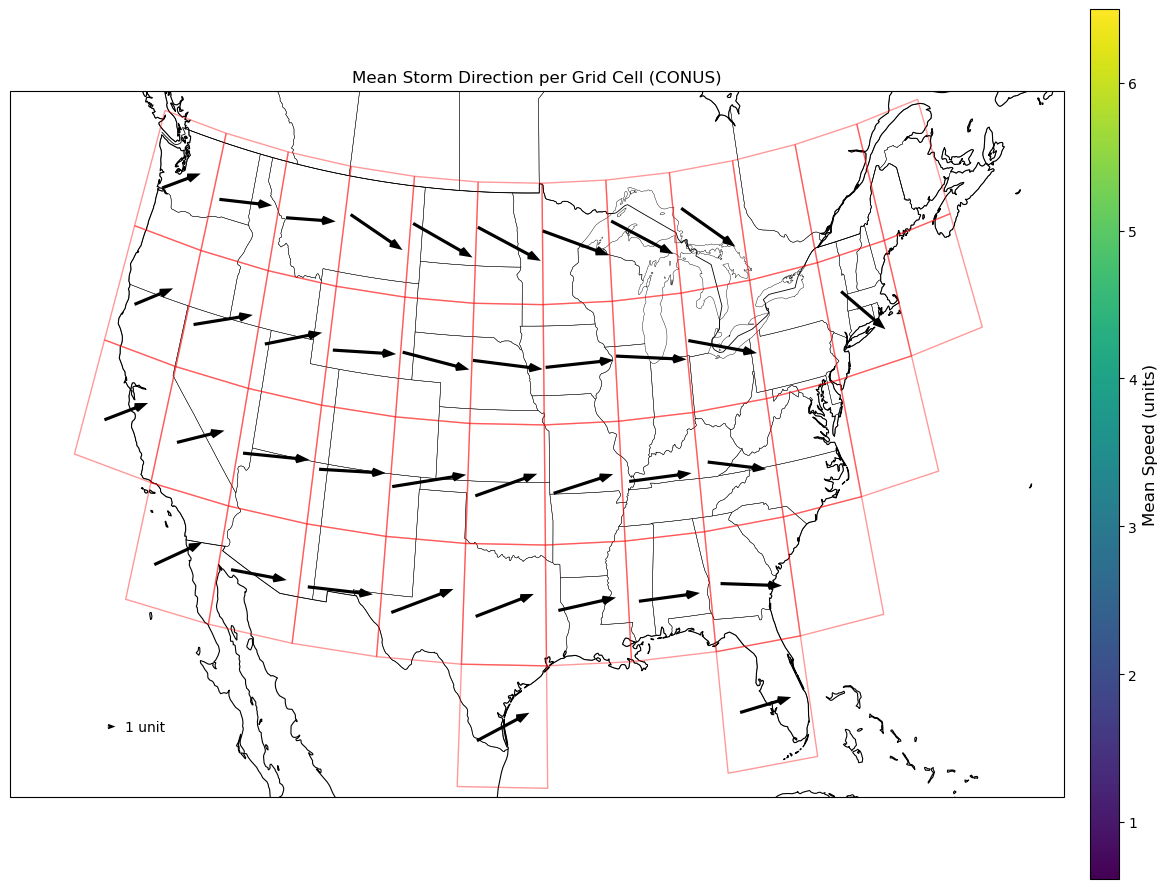

In [16]:
theta_rad = np.deg2rad(conus_dir['angle'].values) + np.pi/2   # convert to radians and rotate 90 deg to point "into" the direction
mag = conus_dir['speed'].values
# Components scaled by magnitude
u = np.sin(theta_rad)*mag    # east-west
v = np.cos(theta_rad)*mag    # north-south

# ── 4) PLOT ON A MAP ─────────────────────────────────────────────────────────
proj = ccrs.LambertConformal(central_longitude=-96, central_latitude=39)
fig = plt.figure(figsize=(13,9))
ax = plt.axes(projection=proj)

# CONUS extent
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)
ax.add_feature(cfeature.STATES, linewidth=0.3)

# (Optional) draw the grid outlines for context:
grid.boundary.plot(ax=ax, transform=ccrs.PlateCarree(), linewidth=1, alpha=0.4, color='red')

xs = conus_dir['centroid_x'].values
ys = conus_dir['centroid_y'].values

# colormap based on magnitude
rainfall = conus_dir['intesity'].values
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=np.nanmin(rainfall), vmax=np.nanmax(rainfall))


# Quiver plot
Q = ax.quiver(
    xs, ys, u, v,   cmap=cmap, norm=norm,  # color by magnitude (or remove this arg if you don't want colormap)
    transform=ccrs.PlateCarree(),
    scale=150,                       # tweak this to adjust arrow lengths
    width=0.003, headwidth=3, headlength=4,
    pivot='middle'
)


cbar = plt.colorbar(Q, ax=ax, orientation='vertical', pad=0.02, aspect=30)
cbar.set_label(f'Mean Speed (units)', fontsize=12)
# Quiver key (adjust label to your units if MAG_COL is real speed)
ax.quiverkey(Q, X=0.1, Y=0.1, U=1.0, label='1 unit', labelpos='E', coordinates='axes')

plt.title("Mean Storm Direction per Grid Cell (CONUS)")
plt.tight_layout()
plt.show()

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return

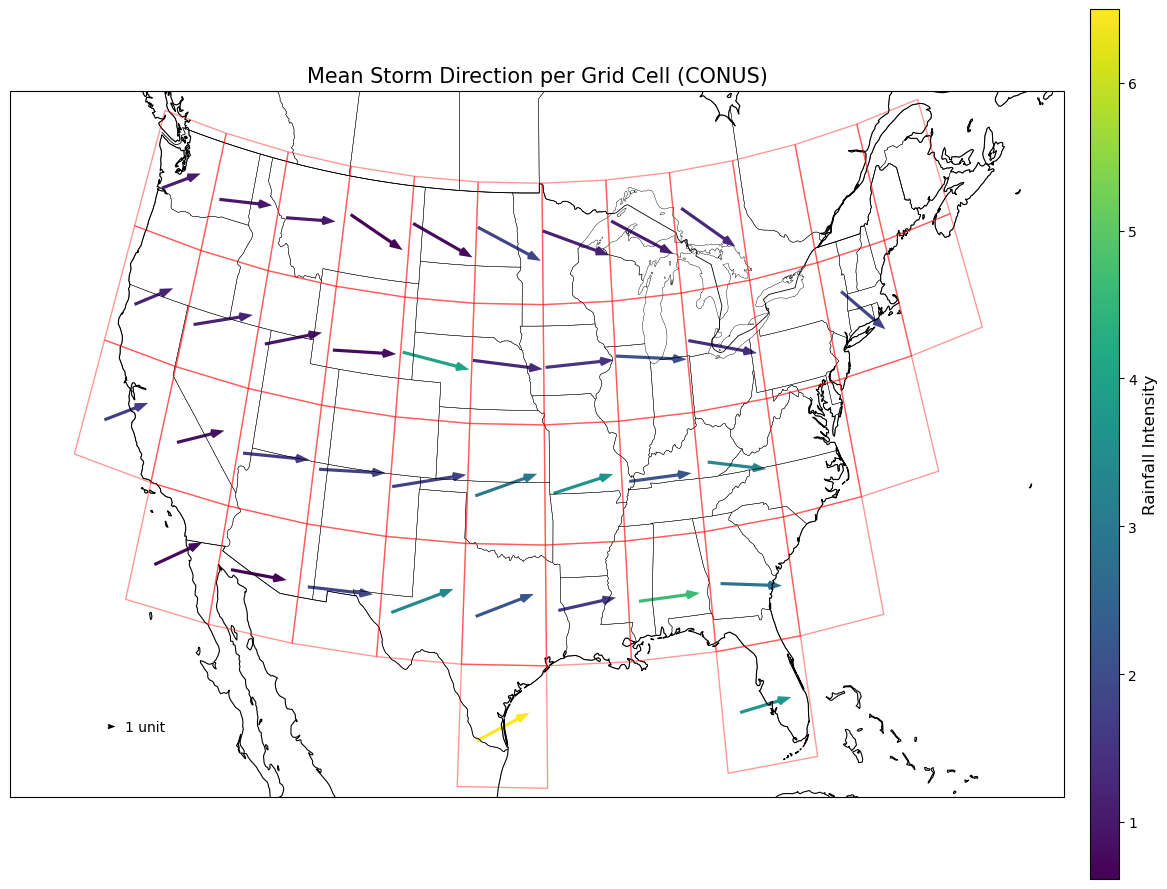

In [17]:


# ── 1) Direction components ─────────────────────────
theta_rad = np.deg2rad(conus_dir['angle'].values) + np.pi/2  # rotate 90° to point "into" direction
mag = conus_dir['speed'].values

u = np.sin(theta_rad) * mag  # east-west
v = np.cos(theta_rad) * mag  # north-south

# ── 2) Setup plot ─────────────────────────
proj = ccrs.LambertConformal(central_longitude=-96, central_latitude=39)
fig = plt.figure(figsize=(13, 9))
ax = plt.axes(projection=proj)

ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)
ax.add_feature(cfeature.STATES, linewidth=0.3)

# Optional: grid outline
grid.boundary.plot(ax=ax, transform=ccrs.PlateCarree(), linewidth=1, alpha=0.4, color='red')

# ── 3) Prepare data ─────────────────────────
xs = conus_dir['centroid_x'].values
ys = conus_dir['centroid_y'].values

# Coloring by intensity
rainfall = conus_dir['intesity'].values
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=np.nanmin(rainfall), vmax=np.nanmax(rainfall))

# ── 4) Quiver Plot ─────────────────────────
Q = ax.quiver(
    xs, ys, u, v, rainfall,         # rainfall controls color
    cmap=cmap, norm=norm,
    transform=ccrs.PlateCarree(),
    scale=150, width=0.003,
    headwidth=3, headlength=4,
    pivot='middle'
)

# Colorbar
cbar = plt.colorbar(Q, ax=ax, orientation='vertical', pad=0.02, aspect=30)
cbar.set_label('Rainfall Intensity', fontsize=12)

# Quiver key (legend for arrow length)
ax.quiverkey(Q, X=0.1, Y=0.1, U=1.0, label='1 unit', labelpos='E', coordinates='axes')

plt.title("Mean Storm Direction per Grid Cell (CONUS)", fontsize=15)
plt.tight_layout()
plt.show()